# FPC1500 Eval: SCPI-Verbindung und TRACE1-Test

> Weiterführend zu SCPI und Python: [SCPI Introduction (PyVISA)](https://www.pyvisa.org/docs/scpi-commands-python) | [SCPI Standard Overview (IVI Foundation)](https://www.ivifoundation.org/About-IVI/scpi.html)

Die Links geben dir einen kompakten Einstieg in Aufbau, typische Kommandostruktur und Python-Implementierung des SCPI-Protokolls.


Dieses Notebook dient als **Verbindungs- und Funktionstest** für den Zugriff auf den FPC1500 über das SCPI-Protokoll.

Ziel:
- Grundlegende Kommunikation mit dem Gerät prüfen (`*IDN?`, `SYST:ERR?`)
- `TRACE1` auslesen und über der Frequenzachse plotten
- Frequenzbereich direkt am Gerät abfragen (`FREQ:STAR?`, `FREQ:STOP?`)
- Optional: Screenshot am Gerät auslösen und als PNG einlesen

Damit kannst du schnell evaluieren, ob Gerät, Netzwerkverbindung und SCPI-Datenpfad grundsätzlich funktionieren.


## Verwendete SCPI-Kommandos und Ablauf

1. **Identifikation / Basis-Check**
   - `*IDN?` -> Gerätekennung (Hersteller, Modell, Seriennummer, FW)
   - `SYST:ERR?` -> Fehlerstatus

2. **X-Achse (Frequenzbereich) bestimmen**
   - `FREQ:STAR?` -> Startfrequenz in Hz
   - `FREQ:STOP?` -> Stopfrequenz in Hz
   - optional `SWE:POIN?` -> Sweep-Punkte

3. **TRACE1 lesen**
   - `TRAC:DATA? TRACE1` -> Messwerte der aktuellen aktiven Darstellung von TRACE1
   - Hinweis: Bedeutung hängt vom eingestellten Anzeigeformat am Gerät ab (z. B. dB, Phase, Smith)

4. **Screenshot erfassen**
   - `HCOP:DEV:LANG PNG`
   - `HCOP:DEST 'MMEM'`
   - `MMEM:NAME '...'`
   - `HCOP:IMM` (Screenshot speichern)
   - `MMEM:DATA? '...'` (Dateiinhalt als Binärdaten auslesen)

Damit ist die vollständige Kommunikationskette vom Query bis zur Dateiübertragung testbar.


## 0) Parameter und Imports


In [1]:
import socket
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

FPC_IP = "192.168.1.10"
FPC_PORT = 5555

SOCKET_TIMEOUT = 10.0
TRACE_READ_MAX_BYTES = 2 * 1024 * 1024
READ_CHUNK_BYTES = 65536
SCREENSHOT_TIMEOUT = 10.0
SCREENSHOT_TRIGGER_DELAY_S = 0.6

OUT_DIR = Path("recordings")
OUT_DIR.mkdir(parents=True, exist_ok=True)
SCREENSHOT_FILENAME = "0-fpc1500-eval_screenshot.png"
SCREENSHOT_LOCAL = OUT_DIR / SCREENSHOT_FILENAME

print(f"SCPI-Ziel: {FPC_IP}:{FPC_PORT}")


SCPI-Ziel: 192.168.1.10:5555


## 1) Hilfsfunktionen für SCPI

Die Funktionen unten kapseln Query/Parse/Binärtransfer, damit die eigentlichen Messzellen kompakt bleiben.


In [2]:
def scpi_query(host: str, port: int, cmd: str, timeout: float = SOCKET_TIMEOUT, max_bytes: int = 4096) -> str:
    msg = (cmd.strip() + "\n").encode("ascii")
    with socket.create_connection((host, port), timeout=timeout) as s:
        s.settimeout(timeout)
        s.sendall(msg)
        data = b""
        while len(data) < max_bytes:
            chunk = s.recv(min(4096, max_bytes - len(data)))
            if not chunk:
                break
            data += chunk
            if b"\n" in chunk:
                break
    return data.decode("ascii", errors="ignore").strip()

def scpi_write(host: str, port: int, cmd: str, timeout: float = SOCKET_TIMEOUT) -> None:
    msg = (cmd.strip() + "\n").encode("ascii")
    with socket.create_connection((host, port), timeout=timeout) as s:
        s.settimeout(timeout)
        s.sendall(msg)

def parse_float_list(raw: str) -> np.ndarray:
    raw = raw.strip()
    if not raw:
        return np.array([], dtype=float)
    vals = [float(x) for x in raw.replace(";", ",").split(",") if x.strip()]
    return np.asarray(vals, dtype=float)

def get_freq_axis(host: str, port: int, n: int) -> np.ndarray:
    if n <= 0:
        return np.array([], dtype=float)
    f_start = float(scpi_query(host, port, "FREQ:STAR?", max_bytes=256))
    f_stop = float(scpi_query(host, port, "FREQ:STOP?", max_bytes=256))
    return np.linspace(f_start, f_stop, n)

def screenshot_save(host: str, port: int, filename: str) -> None:
    scpi_write(host, port, "HCOP:DEV:LANG PNG")
    scpi_write(host, port, "HCOP:DEST 'MMEM'")
    scpi_write(host, port, f"MMEM:NAME '{filename}'")
    scpi_write(host, port, "HCOP:IMM")
    time.sleep(SCREENSHOT_TRIGGER_DELAY_S)

def _parse_ieee_block(blob: bytes) -> bytes:
    if len(blob) < 3 or blob[0:1] != b"#":
        return blob
    n_len_digits = int(chr(blob[1]))
    n_data = int(blob[2:2 + n_len_digits].decode("ascii"))
    i0 = 2 + n_len_digits
    return blob[i0:i0 + n_data]

def screenshot_read(host: str, port: int, filename: str, timeout: float = SCREENSHOT_TIMEOUT) -> bytes | None:
    cmd = f"MMEM:DATA? '{filename}'\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(timeout)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode("ascii"))

        buf = b""
        # IEEE488.2-Blockkopf suchen: #<n><len>
        while b"#" not in buf and len(buf) < 1024:
            chunk = s.recv(256)
            if not chunk:
                return None
            buf += chunk

        if b"#" not in buf:
            return None

        start = buf.index(b"#")
        buf = buf[start:]

        while len(buf) < 2:
            more = s.recv(2 - len(buf))
            if not more:
                return None
            buf += more

        n_digits = int(chr(buf[1]))
        while len(buf) < 2 + n_digits:
            more = s.recv(2 + n_digits - len(buf))
            if not more:
                return None
            buf += more

        data_len = int(buf[2:2 + n_digits].decode("ascii"))
        payload = buf[2 + n_digits:]

        while len(payload) < data_len:
            chunk = s.recv(min(READ_CHUNK_BYTES, data_len - len(payload)))
            if not chunk:
                break
            payload += chunk

        return payload[:data_len] if len(payload) >= data_len else None
    except Exception:
        return None
    finally:
        s.close()


## 2) SCPI-Basischeck: Identifikation und Fehlerstatus


In [3]:
idn = scpi_query(FPC_IP, FPC_PORT, "*IDN?", max_bytes=512)
err = scpi_query(FPC_IP, FPC_PORT, "SYST:ERR?", max_bytes=512)
print(f"*IDN?     -> {idn}")
print(f"SYST:ERR? -> {err}")


*IDN?     -> Rohde&Schwarz,FPC1500,1328.6660K03/102548,V1.50
SYST:ERR? -> -113,"Undefined header;HCOP:DEST 'MMEM'"


## 3) TRACE1 lesen und Frequenzachse aufbauen

Diese Zelle liest `TRACE1` und fragt den am Gerät eingestellten Frequenzbereich ab. Die X-Achse wird als lineare Interpolation zwischen Start/Stop gebildet.


In [4]:
trace_raw = scpi_query(FPC_IP, FPC_PORT, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
trace = parse_float_list(trace_raw)
if trace.size < 2:
    raise RuntimeError("TRACE1 leer oder ungueltig. Bitte TRACE1 am Geraet aktivieren.")

f_start = float(scpi_query(FPC_IP, FPC_PORT, "FREQ:STAR?", max_bytes=256))
f_stop = float(scpi_query(FPC_IP, FPC_PORT, "FREQ:STOP?", max_bytes=256))
try:
    swp_points = int(float(scpi_query(FPC_IP, FPC_PORT, "SWE:POIN?", max_bytes=256)))
except Exception:
    swp_points = -1

freq_hz = np.linspace(f_start, f_stop, trace.size)
print(f"TRACE1 gelesen: N={trace.size}")
print(f"Frequenzbereich: {f_start/1e6:.6f} ... {f_stop/1e6:.6f} MHz")
print(f"SWE:POIN?={swp_points} | TRACE-Len={trace.size}")


TRACE1 gelesen: N=201
Frequenzbereich: 2.000000 ... 200.000000 MHz
SWE:POIN?=201 | TRACE-Len=201


## 4) TRACE1 plotten

Der Plot zeigt die Rohwerte von `TRACE1` über Frequenz. Welche physikalische Bedeutung diese Werte haben, hängt vom aktuell eingestellten Trace-Format am Analyzer ab.


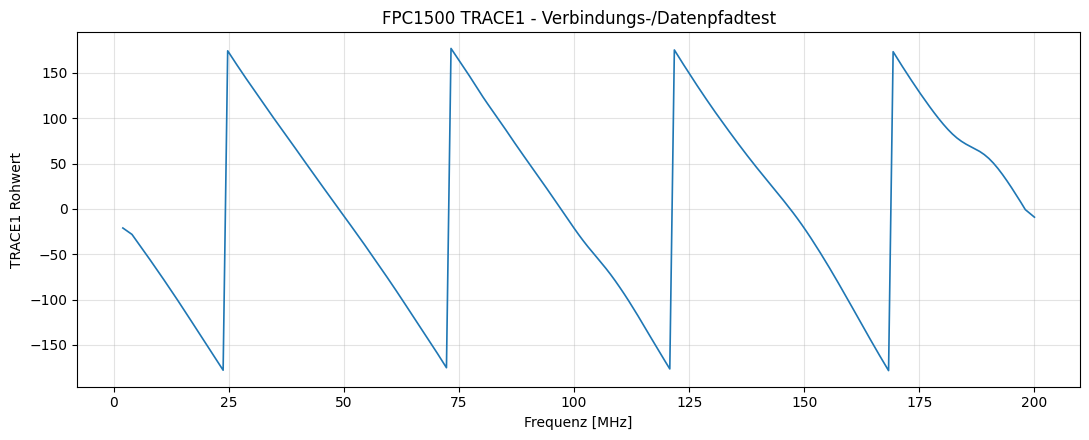

In [5]:
plt.close('all')
fig, ax = plt.subplots(figsize=(11, 4.5), num='FPC1500_TRACE1_EVAL', clear=True)
ax.plot(freq_hz / 1e6, trace, lw=1.2)
ax.set_title('FPC1500 TRACE1 - Verbindungs-/Datenpfadtest')
ax.set_xlabel('Frequenz [MHz]')
ax.set_ylabel('TRACE1 Rohwert')
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


## 5) Screenshot am Gerät auslösen und einlesen

Diese Zelle testet den Dateitransferkanal über SCPI:
1. Screenshot am FPC1500 in den internen Speicher schreiben
2. dieselbe Datei per `MMEM:DATA?` zurücklesen
3. lokal speichern und im Notebook anzeigen


Screenshot gespeichert: recordings\0-fpc1500-eval_screenshot.png (67957 Bytes)


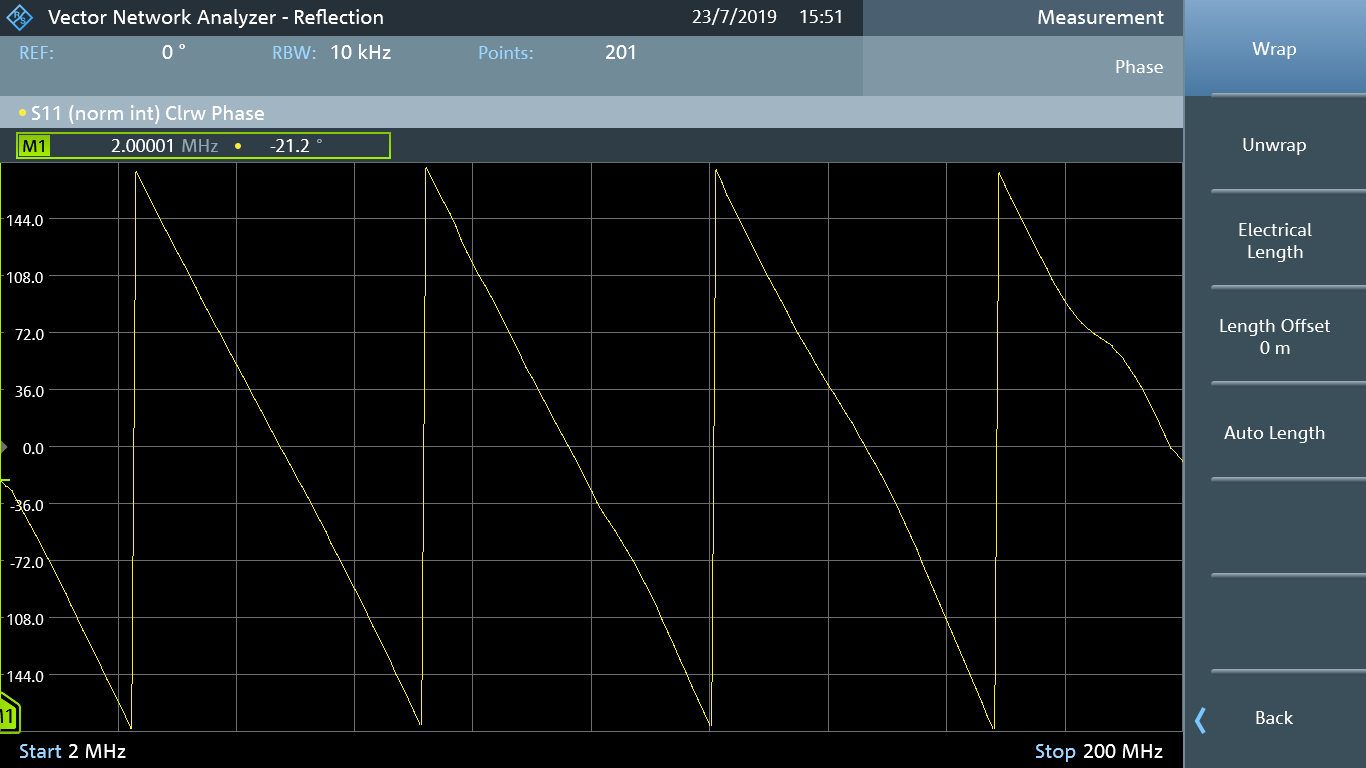

In [6]:
screenshot_save(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
png_bytes = screenshot_read(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME, timeout=SCREENSHOT_TIMEOUT)
if png_bytes is None or len(png_bytes) < 64:
    raise RuntimeError('Screenshot-Transfer fehlgeschlagen oder zu klein (Timeout/Block unvollstaendig).')

SCREENSHOT_LOCAL.write_bytes(png_bytes)
print(f'Screenshot gespeichert: {SCREENSHOT_LOCAL} ({len(png_bytes)} Bytes)')
display(Image(filename=str(SCREENSHOT_LOCAL)))
